# LeRobot Dataset

## Mental Model

![mental-model](./imgs/mental-model.png)

My mental model of a dataset is that it is composed of a number of tasks, each task is composed of a number of episodes, each episode is composed of a number of subtasks, and each subtask is composed of a number of time steps. I am not 100% sure of how subtasks work. For a single task, the dataset has episodes for that task, and each episode has time steps.

The dataset records all the features at each timestep. In this simple "pick and place" example, there is just the observation and the action, there is no reward, so it essentially records $S_t$ and $A_t$. The state is composed of the rotational position of the robot's 6 motors, the image from the gripper camera, and the image from the environment camera. The action consists of the desired rotational position of the 6 motors.

In addition to the state and action, the dataset also includes episode boundaries in the form of `episode_index` field. These start from 0 and increase sequentially till the end of the dataset. All the time steps that belong to the same episode have the same episode index. For the next episode the index restarts at 0. During recording the episode boundary is determined by tehe duration of each recording. They don't seem to have a notion of a "terminal state". When the number of seconds earmarked for the episode have elapsed, the episode is considered terminated.

Each time step is determined by the Frames Per Second. In this case I had recorded my episodes at 30 FPS, so the time step is $\frac{1}{30}$ of a second. This is shown by the `timestamp` field. For each episode they start with 0 and then increase by $\frac{1}{30}$ of a second throughout the duration of the episode. This field resets to 0 at the beginning of each episode.

The `frame_index` is essentially the tick count within the episode. It increases sequentially throughout the episode and then resets to 0 at the beginning of each episode.

The `task_index` field is 0 throughout this dataset because there is just the single task. I think if I merge multiple datasets with different tasks, this field will increase.

The `index_field` is simply a sequentially increasing index across all episodes for the entire dataset.

This mental model is different from the way the dataset is materialized. The episodes are spread across "chunks" and each chunk is stored as a parquet file. Instead of storing individual photos of each time step, the vision data is stored as a video file as it is more efficient. When I instantiate the `LeRobotDataset` object, it will convert the materialized form into the conceptual form I described above.

## Subtasks

Ref: https://huggingface.co/docs/lerobot/dataset_subtask

Within an episode I can further group the time steps into subtasks. I am not sure how to annotate my training data with subtasks as I am recording it. They have a annotation tool for existing datasets, I have not tried it so I don't know how automated it is, but it does seem a bit tedious to have to do this after the fact. The dataset will have two additional fields - subtask and subtask_index after this. The collect-fruit-annotated dataset has subtask annotations if I want to explore it further at any point in the future.

## Reading Datasets

A dataset is usually stored in the huggingface github repo in my workspace under datasets, e.g., https://huggingface.co/avilay/datasets. The full repo ID is my workspace name (usually my username) along with the dataset name, this is usually the name of the task that this dataset has recorded. I can load the entire dataset by providing the repo ID to the `LeRobotDataset(repoid)` constructor. Instead of loading the entire dataset, I can also load only a few cherry picked episodes `LeRobotDataset(repoid, episodes)`.

Everything in the dataset is stored as a PyTorch tensor, even scalar values like the timestamp and the various indexes are all stored as nodim tensors. The images are stored in PyTorch CxHxW format. The only exception is the "task" field which is the name of the task repeated for each of the 25K instances!


This is a dataset in the PyTorch sense of the term. I can use it in my data loader like any other dataset:

```python
dataset = LeRobotDataset("/repo/id")
dataloader = torch.utils.data.DataLoader(dataset, batch_size, shuffle=True)
```

The dataloader will do all the magic it does and create a dict of batched instances, i.e., it will yeild a dict with the same fields as the instance of the dataset, but its values will be a batch instead of a single tensor.

### Tools

Ref: https://huggingface.co/docs/lerobot/using_dataset_tools

#### Editing

`lerobot-edit-dataset` is a versatile tool that can be used to edit existing datasets like deleting episodes, splitting the dataset into train/val/test splits, merging datasets recorded separately, removing features, converting time step images into a video, etc. See usage examples [here](https://huggingface.co/docs/lerobot/using_dataset_tools#usage-examples).

#### Visualization

The coolest tool is the dataset visualization tool. They have an both an [online](https://huggingface.co/spaces/lerobot/visualize_dataset) and a local version. If my dataset is on the huggingface github I can use either. 

```shell
lerobot-dataset-viz \
  --repo-id avilay/pick_and_place_50 \
  --episode-index 0
```

If my dataset is local I can still visualize it in the local visualizer:
```shell
lerobot-dataset-viz \
  --repo-id avilay/pick_and_place_50 \
  --root ./path/to/local/dir \
  --mode local \
  --episode-index 0
```

The local visualizer uses rerun.io and will load the camera streams, robot states, etc.

In [1]:
import matplotlib.pyplot as plt
from lerobot.datasets.lerobot_dataset import LeRobotDataset

In [2]:
# This will look for this repo in the local cache at:
# ~/.cache/huggingface/lerobot/avilay/pick_and_place_50/
repoid = "avilay/pick_and_place_50"

In [3]:
# This is all I need to do to load an existing dataset
dataset = LeRobotDataset(repoid)
len(dataset)

25313

In [4]:
# This is the human readable schema of the dataset
dataset.features

{'action': {'dtype': 'float32',
  'shape': (6,),
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos']},
 'observation.state': {'dtype': 'float32',
  'shape': (6,),
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos']},
 'observation.images.gripper': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels'],
  'info': {'video.height': 480,
   'video.width': 640,
   'video.codec': 'av1',
   'video.pix_fmt': 'yuv420p',
   'video.is_depth_map': False,
   'video.fps': 30,
   'video.channels': 3,
   'has_audio': False}},
 'observation.images.env': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels'],
  'info': {'video.height': 480,
   'video.width': 640,
   'video.codec': 'av1',
   'video.pix_fmt': 'yuv420p',
   'video.is_depth_map': False,
   'video.fps': 30,
  

In [5]:
# I am not sure what is the point of this property, it does not have the correct schema
# The data types are wrong, action is not a List, it is a PyTorch tensor
# In fact all the values are tensors
# There is no mention of the gripper and env images
dataset.hf_features

{'action': List(Value('float32'), length=6),
 'observation.state': List(Value('float32'), length=6),
 'timestamp': Value('float32'),
 'frame_index': Value('int64'),
 'episode_index': Value('int64'),
 'index': Value('int64'),
 'task_index': Value('int64')}

In [6]:
# Given this is a just a dataset, I can access any instance by its index.
instance = dataset[10_000]
print(type(instance))
print(instance.keys())  # instance is a dict
instance

<class 'dict'>
dict_keys(['observation.images.gripper', 'observation.images.env', 'action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'task'])


{'observation.images.gripper': tensor([[[0.4157, 0.4078, 0.4078,  ..., 0.4549, 0.4549, 0.4549],
          [0.4078, 0.4078, 0.4039,  ..., 0.4549, 0.4549, 0.4549],
          [0.4039, 0.4039, 0.4000,  ..., 0.4549, 0.4549, 0.4549],
          ...,
          [0.5255, 0.5294, 0.5294,  ..., 0.8235, 0.8196, 0.8196],
          [0.5255, 0.5255, 0.5294,  ..., 0.8235, 0.8196, 0.8196],
          [0.5216, 0.5255, 0.5255,  ..., 0.8235, 0.8196, 0.8196]],
 
         [[0.5020, 0.4941, 0.4941,  ..., 0.3804, 0.3804, 0.3804],
          [0.4941, 0.4941, 0.4902,  ..., 0.3804, 0.3804, 0.3804],
          [0.4980, 0.4980, 0.4941,  ..., 0.3804, 0.3804, 0.3804],
          ...,
          [0.5176, 0.5216, 0.5216,  ..., 0.7961, 0.7922, 0.7922],
          [0.5176, 0.5176, 0.5216,  ..., 0.7961, 0.7922, 0.7922],
          [0.5137, 0.5176, 0.5176,  ..., 0.7961, 0.7922, 0.7922]],
 
         [[0.4627, 0.4549, 0.4549,  ..., 0.3333, 0.3333, 0.3333],
          [0.4549, 0.4549, 0.4510,  ..., 0.3333, 0.3333, 0.3333],
          

In [7]:
for key, value in instance.items():
    # All the values are pytorch tensors
    # except the [task] key, which is just the same string repeated for all 25K instances in the dataset.
    if key == "task":
        print(f"[{key}]\n\tvalue: {value}")
    else:
        if key.find("images") > -1:
            tvalue = "...tensor..."
        else:
            tvalue = value
        print(f"[{key}]\n\ttype: {type(value)}\tshape: {value.shape}\tdtype: {value.dtype}\n\tvalue: {tvalue}")

[observation.images.gripper]
	type: <class 'torch.Tensor'>	shape: torch.Size([3, 480, 640])	dtype: torch.float32
	value: ...tensor...
[observation.images.env]
	type: <class 'torch.Tensor'>	shape: torch.Size([3, 480, 640])	dtype: torch.float32
	value: ...tensor...
[action]
	type: <class 'torch.Tensor'>	shape: torch.Size([6])	dtype: torch.float32
	value: tensor([ 25.4873, -34.5669,  13.2280,  97.5883,   5.6410,   0.9693])
[observation.state]
	type: <class 'torch.Tensor'>	shape: torch.Size([6])	dtype: torch.float32
	value: tensor([ 40.7407, -20.8633,   2.0777,  98.6290,   5.5922,   1.4997])
[timestamp]
	type: <class 'torch.Tensor'>	shape: torch.Size([])	dtype: torch.float32
	value: 12.600000381469727
[frame_index]
	type: <class 'torch.Tensor'>	shape: torch.Size([])	dtype: torch.int64
	value: 378
[episode_index]
	type: <class 'torch.Tensor'>	shape: torch.Size([])	dtype: torch.int64
	value: 19
[index]
	type: <class 'torch.Tensor'>	shape: torch.Size([])	dtype: torch.int64
	value: 10000
[task

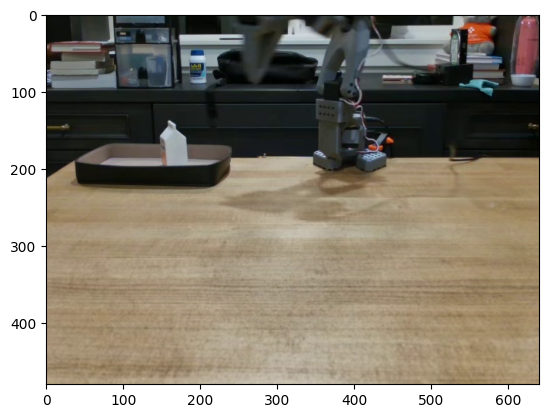

In [8]:
# Images in the dataset are stored in PyTorch's CxHxW format. If I want to render them, I need to transpose them first.
# envimg = np.transpose(instance["observation.images.env"].numpy(), (1, 2, 0))
envimg = instance["observation.images.env"].permute((1, 2, 0)).numpy()
plt.imshow(envimg)

### Indexing and Time Steps

To see how the different indexes like the `frame_index`, the `episode_index`, etc. behave along with the `timestamp` fields beahve it will be useful to load the dataset as a Pandas dataframe.

In [9]:
import pandas as pd
import itables
from pathlib import Path
import pickle
from tqdm import tqdm

itables.init_notebook_mode()

In [10]:
def extract_idxs(dataset):
    timestamps = []
    frame_idxs = []
    episode_idxs = []
    idxs = []
    task_idxs = []
    for d in tqdm(dataset):
        timestamps.append(d["timestamp"].item())
        frame_idxs.append(d["frame_index"].item())
        episode_idxs.append(d["episode_index"].item())
        idxs.append(d["index"].item())
        task_idxs.append(d["task_index"].item())
        
    return {
        "timestamp": timestamps,
        "frame_index": frame_idxs,
        "episode_index": episode_idxs,
        "index": idxs,
        "task_index": task_idxs,
    }

In [11]:
dataset_idxs_pkl = Path("dataset_idxs.pkl")

if not dataset_idxs_pkl.exists():
    with open(dataset_idxs_pkl, "wb") as fout:
        pickle.dump(extract_idxs(dataset), fout)

with open(dataset_idxs_pkl, "rb") as fin:
        dataset_idxs = pickle.load(fin)

In [12]:
df = pd.DataFrame(data=dataset_idxs).set_index("index")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25313 entries, 0 to 25312
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      25313 non-null  float64
 1   frame_index    25313 non-null  int64  
 2   episode_index  25313 non-null  int64  
 3   task_index     25313 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 791.2 KB


In [13]:
df.describe()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [14]:
# Here we can see that each episode has around 506 or 507 time steps. Given that each time step is 1/30 of a secon
# each episode is around 507/30 = 17 seconds long.
df.groupby("episode_index").size()

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [15]:
# Lets look at the first episode.
# The timestamp starts at 0 seconds and increases by 1/30 of a second with each step.
# The frame_index is a proxy for the tick count.
# The episode index remains the same for the entire episode.
# Looking at the last few time steps of this episode, we can see that the last timestamp is 16.9 seconds.
df[df["episode_index"] == 0]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


In [16]:
# Looking at the second episode -
# We can see that the timestamp and frame_index have reset to 0
# The episode index has increased by 1.
# The index continues on.
df[df["episode_index"] == 1]

Loading ITables v2.7.3 from the init_notebook_mode cell... (need help?)


### Cherry Picking Episodes

In [17]:
episodes = LeRobotDataset(repoid, episodes=[0, 24, 49])
len(episodes)

1519

In [18]:
episodes[100]

{'observation.images.gripper': tensor([[[0.4902, 0.4902, 0.4980,  ..., 0.7961, 0.7961, 0.7961],
          [0.4902, 0.4902, 0.4980,  ..., 0.7922, 0.7922, 0.7922],
          [0.4902, 0.4902, 0.4980,  ..., 0.7961, 0.7961, 0.7961],
          ...,
          [0.5804, 0.5804, 0.5765,  ..., 0.4353, 0.4353, 0.4392],
          [0.5765, 0.5765, 0.5725,  ..., 0.4392, 0.4392, 0.4392],
          [0.5725, 0.5725, 0.5647,  ..., 0.4471, 0.4471, 0.4471]],
 
         [[0.4706, 0.4706, 0.4784,  ..., 0.6980, 0.6980, 0.6980],
          [0.4706, 0.4706, 0.4784,  ..., 0.6941, 0.6941, 0.6941],
          [0.4706, 0.4706, 0.4784,  ..., 0.6980, 0.6980, 0.6980],
          ...,
          [0.6392, 0.6392, 0.6353,  ..., 0.4000, 0.4000, 0.4039],
          [0.6353, 0.6353, 0.6314,  ..., 0.4039, 0.4039, 0.4039],
          [0.6314, 0.6314, 0.6235,  ..., 0.4118, 0.4118, 0.4118]],
 
         [[0.3529, 0.3529, 0.3608,  ..., 0.5804, 0.5804, 0.5804],
          [0.3529, 0.3529, 0.3608,  ..., 0.5765, 0.5765, 0.5765],
          

### Training with DataLoader

In [19]:
import torch as th

In [20]:
dataloader = th.utils.data.DataLoader(dataset, batch_size=5, shuffle=False)

In [21]:
it = iter(dataloader)

In [22]:
batch = next(it)
type(batch)

dict

In [23]:
for key, value in batch.items():
    # All the values are pytorch tensors
    # except the [task] key, which is just the same string repeated for all 25K instances in the dataset.
    if key == "task":
        print(f"[{key}]\n\tvalue: {value}")
    else:
        if key.find("images") > -1:
            tvalue = "...tensor..."
        else:
            tvalue = value
        print(f"[{key}]\n\ttype: {type(value)}\tshape: {value.shape}\tdtype: {value.dtype}\n\tvalue: {tvalue}")

[observation.images.gripper]
	type: <class 'torch.Tensor'>	shape: torch.Size([5, 3, 480, 640])	dtype: torch.float32
	value: ...tensor...
[observation.images.env]
	type: <class 'torch.Tensor'>	shape: torch.Size([5, 3, 480, 640])	dtype: torch.float32
	value: ...tensor...
[action]
	type: <class 'torch.Tensor'>	shape: torch.Size([5, 6])	dtype: torch.float32
	value: tensor([[-2.0964e+00, -7.9058e+01,  9.0971e+01,  6.3394e+01, -2.4420e-02,
          1.0501e+00],
        [-2.0964e+00, -7.9058e+01,  9.0971e+01,  6.3394e+01, -2.4420e-02,
          1.0501e+00],
        [-2.0964e+00, -7.9058e+01,  9.0971e+01,  6.3394e+01, -2.4420e-02,
          1.0501e+00],
        [-2.0964e+00, -7.9058e+01,  9.0971e+01,  6.3394e+01, -2.4420e-02,
          1.0501e+00],
        [-2.0964e+00, -7.9058e+01,  9.0971e+01,  6.3394e+01, -2.4420e-02,
          1.0501e+00]])
[observation.state]
	type: <class 'torch.Tensor'>	shape: torch.Size([5, 6])	dtype: torch.float32
	value: tensor([[ -2.3414, -79.0944,  97.1093,  63.49

## Creating Datasets

In [13]:
%reset -f

Creating datasets is a two step process - first is instantiating the dataset with the schema that our instances will be in, and second is actually adding instances that confirm to the provided schema. Both the schema and the data are provided as JSON objects, and the schema is not really a JSON schema object, it is a home grown JSON object that has information about the instances. There are a bunch of convenience functions that help in both of these phases.

TODO: Image

The biggest reason for the conversion between what the robot outputs or expects as input to what the dataset stores is that the robot operates on individual numbers for its motor rotation positions, but the dataset wants this as an array and stores it as a tensor.

### Instantiating the Dataset

Ref: `//lerobot/datasets/lerobot_dataset.py::create`

When instantiating a dataset the most important information I need to give is its schema. In the `pick_and_place` dataset, the following fields constitute the schema:
  * `action`
  * `observation.state`
  * `observation.images.gripper`
  * `observation.images.env`

All the other index fields as well as the `timestamp` field are automatically added, I don't need to specify them.

The convenience function used for this is the `hw_to_dataset_features`. This is defined in `//lerobot/datasets/utils.py` and it does some pretty straightforward conversion of the features that the robot outputs and to dataset features. The logic is that if the feature's value is float then it is an element of a tensor with the tensor's shape being the total number of such features, and if the value of the feature is a tuple, then it is assumed to be a camera feature and it is given a special name `{prefix}.images.{key}`. The schema it outputs is a JSON object that looks like the following:
  * Names of all the features - `action`, `observation.state`, `observation.images.gripper`, `observation.images.env`. Each one of these is a tensor.
  * Each name's value is another JSON that describes the tensor:
    - `dtype` which can be any of the numpy/pytorch datatypes, except there is also `video` as dtype.
    - `shape` which is the shape of the tensor.
    - `names` which is an array of the names of each dimension. These don't seem to be used in the dataset's data.
    - I don't have to specify this, but for video tensors it automatically adds another section called `info` that has the FPS, the codecs used, etc.

In addition to the schema aka features, I also need to give the following:
  * `repo_id`: Datasets are saved in my huggingface.co github. The `repo_id` should include my workspace, e.g., `avilay/my-dataset`.
  * `fps`: FPS at which the video will be captured. I think it will cut the video into as many timesteps as the FPS for each second. I haven't looked at the code to verify this though.

`robot_type` is an optional param that is useful to give. For SO101 arm robot I give `so_follower` which is what either `robot.robot_type` or `robot.name` will return.

Then there are a bunch of other optional params that I can give around video encoding that I don't really care about. I am ok with the defaults it chooses. By default it will store the images as videos but I can change this with `use_videos` param. This set to `True` by default.

In [14]:
from pathlib import Path
from pprint import pprint

from haikunator import Haikunator

from lerobot.robots.so_follower import SO101Follower, SO101FollowerConfig
from lerobot.cameras.opencv.configuration_opencv import OpenCVCameraConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.utils import hw_to_dataset_features

In [15]:
robot_cfg = SO101FollowerConfig(
    port="/dev/ttyACM2",
    id="yantra_robot",
    cameras={
        "gripper": OpenCVCameraConfig(
            index_or_path=Path("/dev/video51"),
            width=640,
            height=480,
            fps=30,
            warmup_s=3,
        ),
        "env": OpenCVCameraConfig(
            index_or_path=Path("/dev/video48"), 
            width=640, 
            height=480, 
            fps=30, 
            warmup_s=3
        ),
    },
)
robot = SO101Follower(robot_cfg)

In [16]:
# This is the schema of the robot's observation and action
pprint(robot.observation_features)
print()
pprint(robot.action_features)

{'elbow_flex.pos': <class 'float'>,
 'env': (480, 640, 3),
 'gripper': (480, 640, 3),
 'gripper.pos': <class 'float'>,
 'shoulder_lift.pos': <class 'float'>,
 'shoulder_pan.pos': <class 'float'>,
 'wrist_flex.pos': <class 'float'>,
 'wrist_roll.pos': <class 'float'>}

{'elbow_flex.pos': <class 'float'>,
 'gripper.pos': <class 'float'>,
 'shoulder_lift.pos': <class 'float'>,
 'shoulder_pan.pos': <class 'float'>,
 'wrist_flex.pos': <class 'float'>,
 'wrist_roll.pos': <class 'float'>}


In [17]:
# This is what we give to the dataset
action_features = hw_to_dataset_features(robot.action_features, "action")  # type: ignore
obs_features = hw_to_dataset_features(robot.observation_features, "observation")  
dataset_features = {**action_features, **obs_features}
dataset_features
# We convert what the robot wants and what we want to give to the dataset using 
# the `hw_to_dataset_features` convenience function.

{'action': {'dtype': 'float32',
  'shape': (6,),
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos']},
 'observation.state': {'dtype': 'float32',
  'shape': (6,),
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos']},
 'observation.images.gripper': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels']},
 'observation.images.env': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels']}}

In [18]:
print(robot.name)
print(robot.robot_type)

so_follower
so_follower


In [19]:
task = Haikunator().haikunate()
dataset = LeRobotDataset.create(
    repo_id=f"avilay/{task}",
    fps=30,
    features=dataset_features,
    robot_type=robot.robot_type
)
dataset

LeRobotDataset({
    Repository ID: 'avilay/purple-art-9819',
    Number of selected episodes: '0',
    Number of selected samples: '0',
    Features: '['action', 'observation.state', 'observation.images.gripper', 'observation.images.env', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

### Adding Instances to the Dataset

Up until now when we were reading the dataset, we did not see numpy anywhere at all. If I look at the imports of the earlier section on Reading, numpy is not imported. Everything was stored as a PyTorch tensor, even scalars like the timestamp and the various indices were stored as PyTorch tensors. But when I query the robot for its state or ask it to perform an action, it expects the motor positions to be as individual numbers and the images as a H X W X C numpy array. Now, I might think that the `build_dataset_frame()` convenience function does the converstion between what the robot expects and what the dataset stores. But I would only be partially right. This function creates an array out of individual numeric values, but everything is still numpy. The images are still H x W X C numpy arrays. The conversion to PyTorch tensors happens later before the data is materialized, but I don't exactly know when. The `build_dataset_frame()` is a very simple function defined in the same `//lerobot/dataset/utils.py` file.

Lerobot has this concept of action and observation processors that are supposed to massage the data coming out of the robot before it is handed off to the `build_dataset_frame()` function. These are generated by calling the convenience function `make_default_processors()`. Based on my current exploration, these are identity functions that don't do anything to the data.

In [20]:
import pickle

import numpy as np

from lerobot.datasets.utils import build_dataset_frame
from lerobot.processor import make_default_processors
from lerobot.utils.constants import ACTION, OBS_STR

In [21]:
# This is the observation that the robot outputs
obs_pkl = Path("obs.pkl")
if not obs_pkl.exists():
    robot.connect(calibrate=False)
    obs = robot.get_observation()
    with open(obs_pkl, "wb") as fout:
        pickle.dump(obs, fout)
    robot.disconnect()
else:
    with open("obs.pkl", "rb") as fin:
        obs = pickle.load(fin)
for key, value in obs.items():
    if isinstance(value, np.ndarray):
        print(f"[{key}] type: {type(value)}, shape: {value.shape}, dtype: {value.dtype}")
    else:
        print(f"[{key}] type: {type(value)}, value: {value}")

[shoulder_pan.pos] type: <class 'float'>, value: 0.6593406593406593
[shoulder_lift.pos] type: <class 'float'>, value: -105.18681318681318
[elbow_flex.pos] type: <class 'float'>, value: 98.1978021978022
[wrist_flex.pos] type: <class 'float'>, value: 59.16483516483517
[wrist_roll.pos] type: <class 'float'>, value: -3.208791208791209
[gripper.pos] type: <class 'float'>, value: 0.6816632583503749
[gripper] type: <class 'numpy.ndarray'>, shape: (480, 640, 3), dtype: uint8
[env] type: <class 'numpy.ndarray'>, shape: (480, 640, 3), dtype: uint8


In [22]:
# All three are identity functions
teleop_action_processor, robot_action_processor, robot_observation_processor = make_default_processors()

In [27]:
# These processors do not change the data in any way
proc_obs = robot_observation_processor(obs)
assert obs.keys() == proc_obs.keys()
for key, value in obs.items():
    if isinstance(value, np.ndarray):
        assert np.array_equal(value, proc_obs[key])
    else:
        assert value == proc_obs[key]

In [29]:
action = {
    "shoulder_pan.pos": 0.6593406593406593,
    "shoulder_lift.pos": -105.18681318681318,
    "elbow_flex.pos": 98.1978021978022,
    "wrist_flex.pos": 59.16483516483517,
    "wrist_roll.pos": -3.208791208791209,
    "gripper.pos": 0.6816632583503749,
}
assert action == robot_action_processor((action, obs))

In [30]:
assert action == teleop_action_processor((action, obs))

In [32]:
# Use the convenience function to convert the obs and action dicts into dataset schema
# But everything is still numpy
obs_frame = build_dataset_frame(dataset_features, obs, prefix=OBS_STR)
for key, value in obs_frame.items():
    tvalue = "...array..." if key.find("images") > -1 else value
    print(f"[{key}] type: {type(value)}, shape: {value.shape}, dtype: {value.dtype}, value: {tvalue}")

[observation.state] type: <class 'numpy.ndarray'>, shape: (6,), dtype: float32, value: [   0.6593407 -105.18681     98.1978      59.164837    -3.2087913
    0.6816633]
[observation.images.gripper] type: <class 'numpy.ndarray'>, shape: (480, 640, 3), dtype: uint8, value: ...array...
[observation.images.env] type: <class 'numpy.ndarray'>, shape: (480, 640, 3), dtype: uint8, value: ...array...


## Full Flow of Creating a Dataset

### Recording Datasets with Teleop

In `//lerobot/scripts/lerobot_record.py::record_loop` this is the flow for recording datasets with a teleop robot:

`dataset` exists, `teleop` exits, and `policy = None`.

```python
obs = robot.get_observation()

# This is a noop
obs_processed = robot_observation_processor(obs)

observation_frame = build_dataset_frame(dataset.features, obs_processed, prefix=OBS_STR)

act = teleop.get_action()

# These are both noops
act_processed_teleop = teleop_action_processor((act, obs))
action_values = act_processed_teleop
robot_action_to_send = robot_action_processor((act_processed_teleop, obs))

_sent_action = robot.send_action(robot_action_to_send)
action_frame = build_dataset_frame(dataset.features, action_values, prefix=ACTION)
frame = {**observation_frame, **action_frame, "task": single_task}
dataset.add_frame(frame)
```

![record_flow_overview](./imgs/record_flow_overview.png)

![record_flow_details](./imgs/record_flow_details.png)

In [1]:
%reset -f

In [2]:
from pathlib import Path

import numpy as np
from PIL import Image
from haikunator import Haikunator

from lerobot.robots.so_follower import SO101Follower, SO101FollowerConfig
from lerobot.cameras.opencv.configuration_opencv import OpenCVCameraConfig
from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.utils import hw_to_dataset_features, build_dataset_frame
from lerobot.utils.constants import ACTION, OBS_STR

In [3]:
rng = np.random.default_rng()

In [4]:
minvals = np.array([
    -13.49760913848877,
    -100.0,
    -35.1693000793457,
    57.2782096862793,
    -0.3663003742694855,
    0.0
])

maxvals = np.array([
    82.49356079101562,
    30.44575309753418,
    96.65914154052734,
    100.0,
    4.126984119415283,
    39.98384475708008
])

In [5]:
def to_positions(ary: np.ndarray) -> dict[str, float|np.ndarray]:
    return {
        "shoulder_pan.pos": ary[0].item(),
        "shoulder_lift.pos": ary[1].item(),
        "elbow_flex.pos": ary[2].item(),
        "wrist_flex.pos": ary[3].item(),
        "wrist_roll.pos": ary[4].item(),
        "gripper.pos": ary[5].item()
    }

In [6]:
robot_cfg = SO101FollowerConfig(
    port="/dev/ttyACM2",
    id="yantra_robot",
    cameras={
        "gripper": OpenCVCameraConfig(
            index_or_path=Path("/dev/video51"),
            width=640,
            height=480,
            fps=30,
            warmup_s=3,
        ),
        "env": OpenCVCameraConfig(
            index_or_path=Path("/dev/video48"), 
            width=640, 
            height=480, 
            fps=30, 
            warmup_s=3
        ),
    },
)
robot = SO101Follower(robot_cfg)

In [7]:
action_features = hw_to_dataset_features(robot.action_features, "action")  # type: ignore
obs_features = hw_to_dataset_features(robot.observation_features, "observation")
dataset_features = {**action_features, **obs_features}

In [8]:
task = Haikunator().haikunate()
dataset = LeRobotDataset.create(
    repo_id=f"avilay/{task}",
    fps=30,
    features=dataset_features,
    robot_type=robot.robot_type
)

In [9]:
def robot_get_observation(t: int) -> dict[str, float|np.ndarray]:
    obs = to_positions(rng.random(6) * (maxvals - minvals) + minvals)
    obs["gripper"] = np.array(Image.open(Path.home()/"temp"/"gripper-frames"/f"{t:04d}.png"))
    obs["env"] = np.array(Image.open(Path.home()/"temp"/"env-frames"/f"{t:04d}.png"))
    return obs


def teleop_get_action() -> dict[str, float|np.ndarray]:
    return to_positions(rng.random(6) * (maxvals - minvals) + minvals)

In [10]:
# Lets generate 2 episodes of 3 seconds each at 30 FPS
for episode in range(2):
    for t in range(1, 91):
        # Pretend we are calling robot.get_observation() here.
        obs = robot_get_observation(t)

        # Pretend we are calling teleop.get_action() here
        action = teleop_get_action()

        # robot.send_action(action)

        obs_frame = build_dataset_frame(dataset_features, obs, prefix=OBS_STR)
        action_frame = build_dataset_frame(dataset_features, action, prefix=ACTION)
        ds_frame = {**obs_frame, **action_frame, "task": task}
        dataset.add_frame(ds_frame)
    dataset.save_episode()
dataset.finalize()
# dataset.push_to_hub()

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT 

Map:   0%|          | 0/90 [00:00<?, ? examples/s]

Svt[info]: -------------------------------------------
Svt[info]: SVT [version]:	SVT-AV1 Encoder Lib v3.0.0
Svt[info]: SVT [build]  :	GCC 14.2.1 20250110 (Red Hat 14.2.1-7)	 64 bit
Svt[info]: LIB Build date: Jul  3 2025 03:14:07
Svt[info]: -------------------------------------------
Svt[warn]: Preset M12 is mapped to M10.
Svt[info]: Level of Parallelism: 5
Svt[info]: Number of PPCS 76
Svt[info]: [asm level on system : up to avx2]
Svt[info]: [asm level selected : up to avx2]
Svt[info]: -------------------------------------------
Svt[info]: SVT [config]: main profile	tier (auto)	level (auto)
Svt[info]: SVT [config]: width / height / fps numerator / fps denominator 		: 640 / 480 / 30 / 1
Svt[info]: SVT [config]: bit-depth / color format 					: 8 / YUV420
Svt[info]: SVT [config]: preset / tune / pred struct 					: 10 / PSNR / random access
Svt[info]: SVT [config]: gop size / mini-gop size / key-frame type 			: 2 / 16 / key frame
Svt[info]: SVT [config]: BRC mode / rate factor 					: CRF / 

I won't be able to read this dataset the way it is. I have to re-instantiate it from the repo to be able to use it.

In [11]:
ds = LeRobotDataset(f"avilay/{task}")
ds

LeRobotDataset({
    Repository ID: 'avilay/sparkling-hall-3104',
    Number of selected episodes: '2',
    Number of selected samples: '180',
    Features: '['action', 'observation.state', 'observation.images.gripper', 'observation.images.env', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})',

In [12]:
ds[30]

{'observation.images.gripper': tensor([[[0.7098, 0.7020, 0.6941,  ..., 0.8392, 0.8471, 0.8510],
          [0.7059, 0.7020, 0.6941,  ..., 0.8353, 0.8431, 0.8431],
          [0.7059, 0.6980, 0.6824,  ..., 0.8235, 0.8235, 0.8235],
          ...,
          [0.7255, 0.7255, 0.7255,  ..., 0.5255, 0.5255, 0.5216],
          [0.7216, 0.7255, 0.7255,  ..., 0.5255, 0.5255, 0.5255],
          [0.7216, 0.7216, 0.7255,  ..., 0.5255, 0.5255, 0.5255]],
 
         [[0.6902, 0.6824, 0.6745,  ..., 0.7059, 0.7137, 0.7176],
          [0.6863, 0.6824, 0.6745,  ..., 0.7020, 0.7098, 0.7098],
          [0.6863, 0.6784, 0.6627,  ..., 0.6902, 0.6902, 0.6902],
          ...,
          [0.7765, 0.7765, 0.7765,  ..., 0.4275, 0.4275, 0.4235],
          [0.7725, 0.7765, 0.7765,  ..., 0.4275, 0.4275, 0.4275],
          [0.7725, 0.7725, 0.7765,  ..., 0.4275, 0.4275, 0.4275]],
 
         [[0.5725, 0.5647, 0.5569,  ..., 0.5882, 0.5961, 0.6000],
          [0.5686, 0.5647, 0.5569,  ..., 0.5843, 0.5922, 0.5922],
          